In [4]:
import model as md
import numpy as np
import matplotlib.pyplot as plt
import importlib
importlib.reload(md)
N = 1000


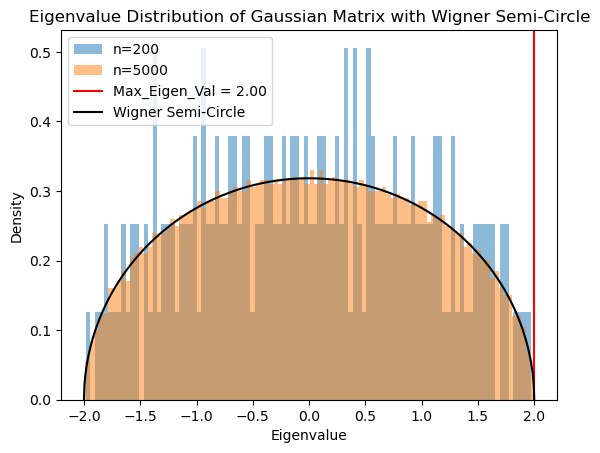

In [7]:
for N in [200, 5000]:

    M = md.symmetric_gaussian_matrix(N)
    md.plot_eigenvalue_distribution(M, N)

md.plot_Max_Eigenval()
md.plot_Wigner_Semi_Circle()

plt.title('Eigenvalue Distribution of Gaussian Matrix with Wigner Semi-Circle')
plt.legend()
plt.savefig('../Plots/Spike/no_spike.png')
md.show()

In [ ]:
#Location of the Spikes:
lambas = [1, 2, 3, 5]

for lamba in lambas:
    spiked_gaussian = md.spiked_gaussian_matrix(N, lamba)
    md.plot_eigenvalue_distribution(spiked_gaussian, N, True)
    md.plot_Max_Eigenval(lamba)
md.plot_Wigner_Semi_Circle()
plt.title('Eigenvalue Distribution of Gaussian Matrix with Spike different values of lambda')
plt.legend()

plt.savefig('../Plots/Spike/many_spikes.png')
md.show()

ValueError: x and y must be the same size

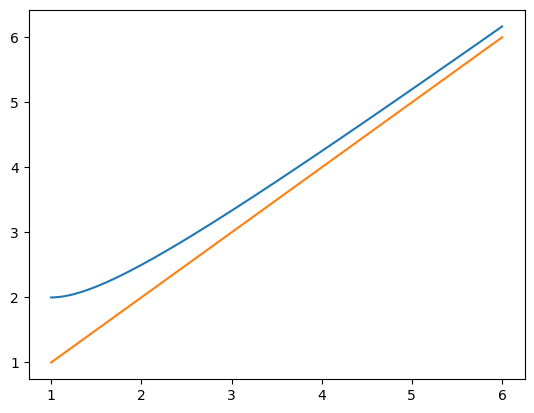

In [ ]:
md.first_look_at_BBP_transi(N = 500)

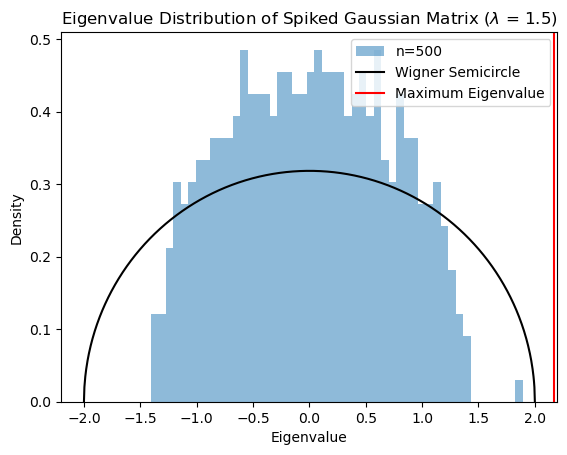

In [ ]:
rhos = np.linspace(0, 1, 3)
lamba_1 = 2
lamba_2 = 3
alpha = 0.2

for rho in rhos:
    M = md.spec(N, lamba_1, lamba_2, rho, alpha)
    md.plot_eigenvalue_distribution(M, N, False)
plt.show()

KeyboardInterrupt: 

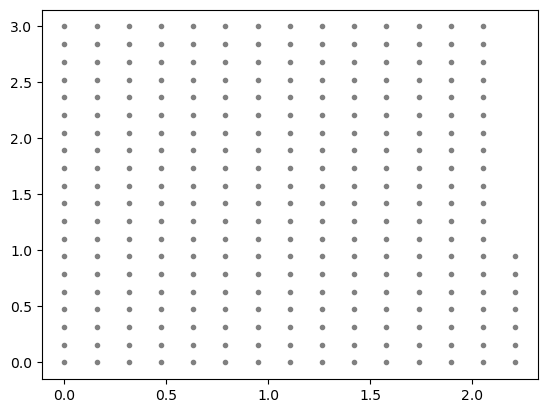

In [ ]:
#k1= 5
#k2= 7
mean = [0, 0]
N=500
rho = 0.8
les_m1 = []
#les_m1_recovered = []
les_m2 = []
#les_m2_recovered = []
#alphas = np.linspace(0, 1, 100)
alphas = [0.5]
ep = 1e-1
#for rho in np.linspace(0, 0.9, 10):
#    les_m1 = []
#    les_m2 = []
K = 20
for k1 in np.linspace(0, 3, K):
    for k2 in np.linspace(0, 3, K):
        for alpha in alphas:
            cov = [[1, rho],
            [rho, 1]]
            X = np.random.multivariate_normal(mean, cov, N)
            X1, X2 = X[:, 0], X[:, 1]
            x1_true = X[:, 0] # unit vector
            x2_true = X[:, 1]  # unit vector
            #X1 = X1/np.linalg.norm(X1)
            #X2 = X2/np.linalg.norm(X2)
            X1 = k1 * np.outer(x1_true,x1_true)
            X2 = k2 * np.outer(x2_true,x2_true)

            Y1 = symmetric_gaussian_matrix(N) + X1
            Y2 = symmetric_gaussian_matrix(N) + X2
            Y = alpha * Y1 + (1-alpha) * Y2
            eigvals, eigvecs = np.linalg.eigh(Y)
            x_hat = eigvecs[:, -1]
            m1 = abs(1/N * np.dot(x_hat, x1_true))
            m2 = abs(1/N * np.dot(x_hat, x2_true))
            les_m1.append(m1)
            les_m2.append(m2)

            if m1 > ep and m2 > ep:
                plt.scatter(k1, k2, color='blue', marker='.')
            elif (m1 > ep and m2 <= ep):
                plt.scatter(k1, k2, color='red', marker='.')
            elif (m1 <= ep and m2 > ep):
                plt.scatter(k1, k2, color='green', marker='.')
            else:
                plt.scatter(k1, k2, color='gray', marker='.')
#ax.set_xlabel("m1 (overlap with x1)")
#ax.set_ylabel("m2 (overlap with x2)")
ax.set_title("Phase transition")
plt.show()




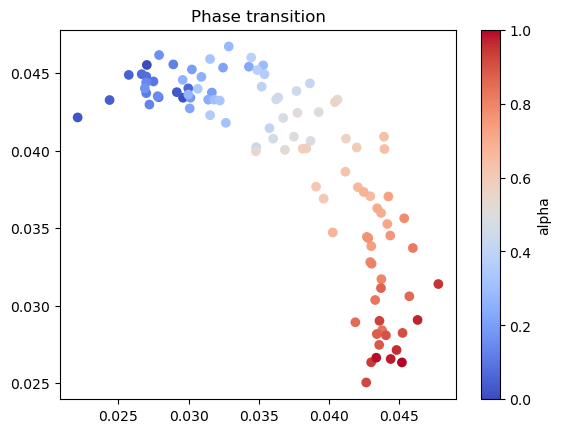

In [ ]:
k1= 5
k2= 7
mean = [0, 0]
N=500
rho = 0.6
les_m1 = []
#les_m1_recovered = []
les_m2 = []
#les_m2_recovered = []
alphas = np.linspace(0, 1, 100)
#alphas = [0.6]
ep = 1e-2
#for rho in np.linspace(0, 0.9, 10):
#    les_m1 = []
#    les_m2 = []

for alpha in alphas:
    cov = [[1, rho],
    [rho, 1]]
    X = np.random.multivariate_normal(mean, cov, N)
    X1, X2 = X[:, 0], X[:, 1]
    x1_true, x2_true = X1.copy(), X2.copy()
    X1 = X1/np.linalg.norm(X1) # the true signals
    X2 = X2/np.linalg.norm(X2)
    X1 = k1 * np.outer(X1,X1)
    X2 = k2 * np.outer(X2,X2)

    Y1 = symmetric_gaussian_matrix(N) + X1
    Y2 = symmetric_gaussian_matrix(N) + X2
    Y = alpha * Y1 + (1-alpha) * Y2
    eigvals, eigvecs = np.linalg.eigh(Y)
    x_hat = eigvecs[:, -1]
    m1 = abs((1 / N) * np.dot(x_hat, x1_true))
    m2 = abs((1 / N) * np.dot(x_hat, x2_true))
    les_m1.append(m1)
    les_m2.append(m2)
sc = plt.scatter(les_m1, les_m2, c=alphas, cmap='coolwarm', marker='o')
plt.colorbar(sc, label='alpha')
plt.title("Phase transition")
plt.show()




In [17]:
#def symmetric_gaussian_matrix(n):
#    G = np.random.randn(n, n)/ np.sqrt(n) 
#    return (G + G.T) / 2 
importlib.reload(md)
N = 1000
k1 = 2
k2 = 2
rho = 0.01
#alphas = np.linspace(0.5, 1, 5)
alphas = [0, 0.1, 0.5, 0.6, 0.7, 0.8, 0.9]
for alpha in alphas:
    cov = [[1, rho],
                [rho, 1]]
    X = np.random.multivariate_normal(mean, cov, N)
    X1, X2 = X[:, 0], X[:, 1]
    x1_true = X[:, 0] / np.linalg.norm(X[:, 0])   # unit vector
    x2_true = X[:, 1] / np.linalg.norm(X[:, 1])   # unit vector
    X1 = k1 * np.outer(x1_true,x1_true)
    X2 = k2 * np.outer(x2_true,x2_true)
    Y1 = symmetric_gaussian_matrix(N) + X1
    Y2 = symmetric_gaussian_matrix(N) + X2
    Y = (alpha * Y1 + np.sqrt(1-alpha**2) * Y2)
    x_hat = np.linalg.eigh(Y)[1][:, -1]
    m1 = abs((1 / N) * np.dot(x_hat, x1_true))
    m2 = abs((1 / N) * np.dot(x_hat, x2_true))
    eigvals, eigvecs = np.linalg.eigh(Y)



    plt.hist(eigvals, bins=100, density=True, alpha=0.5, label=f'n={N}')
    plt.show()

NameError: name 'mean' is not defined

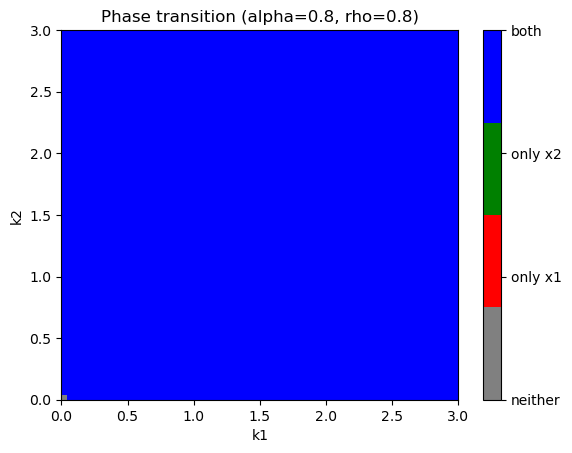

In [ ]:
def symmetric_gaussian_matrix(n):
    G = np.random.randn(n, n)
    return (G + G.T) / np.sqrt(2 * n) 


mean = [0, 0]
N = 1000
rho = 0.8
alpha = 0.8
ep = 1e-2
K = 70
n_repeats = 3
k_values = np.linspace(0, 3, K)  

grid = np.zeros((K, K))  

for i, k1 in enumerate(k_values):
    for j, k2 in enumerate(k_values):
        m1_avg, m2_avg = 0, 0
        for _ in range(n_repeats):
            cov = [[1, rho], [rho, 1]]
            X = np.random.multivariate_normal(mean, cov, N)
            x1_true = X[:, 0]
            x2_true = X[:, 1]
            X1 = k1 * np.outer(x1_true,x1_true)
            X2 = k2 * np.outer(x2_true, x2_true)
            Y = alpha * (symmetric_gaussian_matrix(N) + X1) + (1 - alpha) * (symmetric_gaussian_matrix(N) + X2)
            x_hat = np.linalg.eigh(Y)[1][:, -1]
            m1_avg += abs(1/N*np.dot(x_hat, x1_true))
            m2_avg += abs(1/N*np.dot(x_hat, x2_true))

        m1, m2 = m1_avg / n_repeats, m2_avg / n_repeats
        if   m1 > ep and m2 > ep:  grid[i, j] = 3  # both
        elif m1 > ep:              grid[i, j] = 1  # only x1
        elif m2 > ep:              grid[i, j] = 2  # only x2
        else:                      grid[i, j] = 0  # neither

cmap = plt.cm.colors.ListedColormap(['gray', 'red', 'green', 'blue'])
plt.imshow(grid, origin='lower', cmap=cmap, vmin=0, vmax=3, extent=[k_values[0], k_values[-1], k_values[0], k_values[-1]], aspect='auto')
plt.colorbar(ticks=[0,1,2,3], label='').set_ticklabels(['neither', 'only x1', 'only x2', 'both'])
plt.xlabel("k1")
plt.ylabel("k2")
plt.title(f"Phase transition (alpha={alpha}, rho={rho})")
plt.show()